In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('Skyserver_SQL12_20_2025 1_03_09 PM.csv', skiprows=1)

# Display basic information
print("="*60)
print("✓ DATASET LOADED SUCCESSFULLY!")
print("="*60)
print(f"\n📊 Total Galaxies: {df.shape[0]}")
print(f"📋 Total Features: {df.shape[1]}")
print(f"\n✅ Column Names:")
print(df.columns.tolist())
print(f"\n🔍 First 5 Galaxies:")
print(df.head())


✓ DATASET LOADED SUCCESSFULLY!

📊 Total Galaxies: 50000
📋 Total Features: 13

✅ Column Names:
['objID', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift', 'petroRad_r', 'petroR50_r', 'petroR90_r']

🔍 First 5 Galaxies:
                 objID          ra       dec         u         g         r  \
0  1237648704053051559  212.703394 -0.311232  20.21828  18.19926  17.08501   
1  1237648704054493472  216.084861 -0.356042  19.87009  18.23743  17.29150   
2  1237648704054493469  216.083872 -0.218972  19.48882  18.42888  17.95833   
3  1237648704054493451  216.072909 -0.217397  19.70112  17.92930  16.87107   
4  1237648704054493418  216.041684 -0.229946  20.30025  18.59996  17.56902   

          i         z   class  redshift  petroRad_r  petroR50_r  petroR90_r  
0  16.62111  16.21428  GALAXY  0.137741    3.911826    1.694031    5.226721  
1  16.82742  16.46935  GALAXY  0.134676    7.755181    3.508191    8.404374  
2  17.53517  17.37079  GALAXY  0.083922    3.233896    1.576273    3.44

In [2]:
# Check data quality
print("="*60)
print("📊 DATA QUALITY CHECK")
print("="*60)

# 1. Missing values
print("\n❓ Missing Values:")
print(df.isnull().sum())

# 2. Data types
print("\n📈 Data Types:")
print(df.dtypes)

# 3. Basic statistics
print("\n📉 Basic Statistics:")
print(df.describe())

# 4. Check for unusual values in Petrosian radii
print("\n⚠️  Checking for -9999 (missing data indicators):")
print(f"petroRad_r:  {(df['petroRad_r'] == -9999).sum()} rows")
print(f"petroR50_r:  {(df['petroR50_r'] == -9999).sum()} rows")
print(f"petroR90_r:  {(df['petroR90_r'] == -9999).sum()} rows")


📊 DATA QUALITY CHECK

❓ Missing Values:
objID         0
ra            0
dec           0
u             0
g             0
r             0
i             0
z             0
class         0
redshift      0
petroRad_r    0
petroR50_r    0
petroR90_r    0
dtype: int64

📈 Data Types:
objID           int64
ra            float64
dec           float64
u             float64
g             float64
r             float64
i             float64
z             float64
class          object
redshift      float64
petroRad_r    float64
petroR50_r    float64
petroR90_r    float64
dtype: object

📉 Basic Statistics:
              objID            ra           dec             u             g  \
count  5.000000e+04  50000.000000  50000.000000  50000.000000  50000.000000   
mean   1.237650e+18    163.640566     23.381269     20.110074     18.385650   
std    1.277521e+12     59.743912     27.513499      1.471349      1.292962   
min    1.237646e+18      0.978167    -10.652759     14.483200     13.013970   
25%    1

In [3]:
# Replace -9999 with NaN
df['petroR50_r'] = df['petroR50_r'].replace(-9999, np.nan)
df['petroR90_r'] = df['petroR90_r'].replace(-9999, np.nan)

# Fill NaN with median values
df['petroR50_r'].fillna(df['petroR50_r'].median(), inplace=True)
df['petroR90_r'].fillna(df['petroR90_r'].median(), inplace=True)

# Verify cleaning
print("="*60)
print("✓ DATA CLEANING COMPLETED!")
print("="*60)
print("\n✅ Verification:")
print(f"petroR50_r - Missing values: {df['petroR50_r'].isnull().sum()}")
print(f"petroR50_r - Min value: {df['petroR50_r'].min():.3f}")
print(f"\npetroR90_r - Missing values: {df['petroR90_r'].isnull().sum()}")
print(f"petroR90_r - Min value: {df['petroR90_r'].min():.3f}")
print(f"\n📊 Total clean galaxies: {df.shape[0]}")


✓ DATA CLEANING COMPLETED!

✅ Verification:
petroR50_r - Missing values: 0
petroR50_r - Min value: 0.109

petroR90_r - Missing values: 0
petroR90_r - Min value: 0.193

📊 Total clean galaxies: 50000


/tmp/ipython-input-2676413639.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['petroR50_r'].fillna(df['petroR50_r'].median(), inplace=True)
/tmp/ipython-input-2676413639.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [4]:
# Create galaxy color features (magnitude differences)
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

# Verify new features
print("="*60)
print("✓ GALAXY COLOR FEATURES CREATED!")
print("="*60)
print(f"\n📊 Total Features Now: {df.shape[1]}")
print(f"\n✅ New Color Columns:")
print(['u-g', 'g-r', 'r-i', 'i-z'])
print(f"\n🔍 First 5 Galaxies with Colors:")
print(df[['objID', 'u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']].head())
print(f"\n📈 Color Statistics:")
print(df[['u-g', 'g-r', 'r-i', 'i-z']].describe())


✓ GALAXY COLOR FEATURES CREATED!

📊 Total Features Now: 17

✅ New Color Columns:
['u-g', 'g-r', 'r-i', 'i-z']

🔍 First 5 Galaxies with Colors:
                 objID         u         g         r         i         z  \
0  1237648704053051559  20.21828  18.19926  17.08501  16.62111  16.21428   
1  1237648704054493472  19.87009  18.23743  17.29150  16.82742  16.46935   
2  1237648704054493469  19.48882  18.42888  17.95833  17.53517  17.37079   
3  1237648704054493451  19.70112  17.92930  16.87107  16.37746  16.04375   
4  1237648704054493418  20.30025  18.59996  17.56902  17.07393  16.73525   

       u-g      g-r      r-i      i-z  redshift  
0  2.01902  1.11425  0.46390  0.40683  0.137741  
1  1.63266  0.94593  0.46408  0.35807  0.134676  
2  1.05994  0.47055  0.42316  0.16438  0.083922  
3  1.77182  1.05823  0.49361  0.33371  0.150579  
4  1.70029  1.03094  0.49509  0.33868  0.174182  

📈 Color Statistics:
                u-g           g-r           r-i           i-z
count  50000.0000

In [5]:
# Select features for clustering (exclude objID, ra, dec, class)
feature_columns = ['u', 'g', 'r', 'i', 'z',
                   'redshift',
                   'petroRad_r', 'petroR50_r', 'petroR90_r',
                   'u-g', 'g-r', 'r-i', 'i-z']

# Create feature matrix
X = df[feature_columns].copy()

print("="*60)
print("✓ FEATURES SELECTED FOR CLUSTERING!")
print("="*60)
print(f"\n📊 Feature Matrix Shape: {X.shape}")
print(f"   (Rows = Galaxies, Columns = Features)")
print(f"\n✅ Selected Features ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"   {i}. {col}")
print(f"\n🔍 First 5 Rows:")
print(X.head())
print(f"\n📈 Feature Statistics:")
print(X.describe())


✓ FEATURES SELECTED FOR CLUSTERING!

📊 Feature Matrix Shape: (50000, 13)
   (Rows = Galaxies, Columns = Features)

✅ Selected Features (13):
   1. u
   2. g
   3. r
   4. i
   5. z
   6. redshift
   7. petroRad_r
   8. petroR50_r
   9. petroR90_r
   10. u-g
   11. g-r
   12. r-i
   13. i-z

🔍 First 5 Rows:
          u         g         r         i         z  redshift  petroRad_r  \
0  20.21828  18.19926  17.08501  16.62111  16.21428  0.137741    3.911826   
1  19.87009  18.23743  17.29150  16.82742  16.46935  0.134676    7.755181   
2  19.48882  18.42888  17.95833  17.53517  17.37079  0.083922    3.233896   
3  19.70112  17.92930  16.87107  16.37746  16.04375  0.150579    6.814795   
4  20.30025  18.59996  17.56902  17.07393  16.73525  0.174182    4.501798   

   petroR50_r  petroR90_r      u-g      g-r      r-i      i-z  
0    1.694031    5.226721  2.01902  1.11425  0.46390  0.40683  
1    3.508191    8.404374  1.63266  0.94593  0.46408  0.35807  
2    1.576273    3.442507  1.05994  0

In [6]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

print("="*60)
print("✓ FEATURES SCALED SUCCESSFULLY!")
print("="*60)
print(f"\n📊 Scaled Data Shape: {X_scaled.shape}")
print(f"\n✅ Verification (all features should have mean≈0, std≈1):")
print(X_scaled_df.describe())
print(f"\n🔍 First 5 Scaled Galaxies:")
print(X_scaled_df.head())


✓ FEATURES SCALED SUCCESSFULLY!

📊 Scaled Data Shape: (50000, 13)

✅ Verification (all features should have mean≈0, std≈1):
                  u             g             r             i             z  \
count  5.000000e+04  5.000000e+04  5.000000e+04  5.000000e+04  5.000000e+04   
mean   1.508553e-15 -4.035883e-17  7.105427e-18 -1.273293e-15 -3.898037e-16   
std    1.000010e+00  1.000010e+00  1.000010e+00  1.000010e+00  1.000010e+00   
min   -3.824333e+00 -4.154594e+00 -4.432505e+00 -4.547711e+00 -4.459772e+00   
25%   -6.262673e-01 -5.455221e-01 -4.832314e-01 -4.737678e-01 -4.753080e-01   
50%   -1.267854e-01 -1.013806e-01 -5.201594e-02 -4.644025e-02 -5.662898e-02   
75%    4.618281e-01  3.386771e-01  2.434030e-01  2.541891e-01  2.609060e-01   
max    6.630522e+00  7.742847e+00  1.008325e+01  9.139565e+00  8.569957e+00   

           redshift    petroRad_r    petroR50_r    petroR90_r           u-g  \
count  5.000000e+04  5.000000e+04  5.000000e+04  5.000000e+04  5.000000e+04   
mean  

In [7]:
from sklearn.decomposition import PCA

# Apply PCA with all 13 components
pca = PCA(n_components=13)
X_pca = pca.fit_transform(X_scaled)

# Display results
print("="*60)
print("✓ PCA APPLIED SUCCESSFULLY!")
print("="*60)
print(f"\n📊 PCA Shape: {X_pca.shape}")
print(f"\n📈 Explained Variance Ratio (per component):")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"   PC{i}: {var:.4f} ({var*100:.2f}%)")

print(f"\n📊 Cumulative Explained Variance:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cum in enumerate(cumsum, 1):
    print(f"   PC1-PC{i}: {cum:.4f} ({cum*100:.2f}%)")

print(f"\n✅ Key Insights:")
print(f"   • First 2 PCs explain: {cumsum[1]*100:.2f}% of variance")
print(f"   • First 3 PCs explain: {cumsum[2]*100:.2f}% of variance")
print(f"   • First 5 PCs explain: {cumsum[4]*100:.2f}% of variance")


✓ PCA APPLIED SUCCESSFULLY!

📊 PCA Shape: (50000, 13)

📈 Explained Variance Ratio (per component):
   PC1: 0.4822 (48.22%)
   PC2: 0.1679 (16.79%)
   PC3: 0.1219 (12.19%)
   PC4: 0.0906 (9.06%)
   PC5: 0.0571 (5.71%)
   PC6: 0.0502 (5.02%)
   PC7: 0.0200 (2.00%)
   PC8: 0.0057 (0.57%)
   PC9: 0.0044 (0.44%)
   PC10: 0.0000 (0.00%)
   PC11: 0.0000 (0.00%)
   PC12: 0.0000 (0.00%)
   PC13: 0.0000 (0.00%)

📊 Cumulative Explained Variance:
   PC1-PC1: 0.4822 (48.22%)
   PC1-PC2: 0.6501 (65.01%)
   PC1-PC3: 0.7721 (77.21%)
   PC1-PC4: 0.8627 (86.27%)
   PC1-PC5: 0.9198 (91.98%)
   PC1-PC6: 0.9699 (96.99%)
   PC1-PC7: 0.9899 (98.99%)
   PC1-PC8: 0.9956 (99.56%)
   PC1-PC9: 1.0000 (100.00%)
   PC1-PC10: 1.0000 (100.00%)
   PC1-PC11: 1.0000 (100.00%)
   PC1-PC12: 1.0000 (100.00%)
   PC1-PC13: 1.0000 (100.00%)

✅ Key Insights:
   • First 2 PCs explain: 65.01% of variance
   • First 3 PCs explain: 77.21% of variance
   • First 5 PCs explain: 91.98% of variance


In [8]:
# Apply PCA with 5 components
pca_5 = PCA(n_components=5)
X_pca_5 = pca_5.fit_transform(X_scaled)

# Create DataFrame
pca_columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
X_pca_5_df = pd.DataFrame(X_pca_5, columns=pca_columns)

print("="*60)
print("✓ 5-COMPONENT PCA COMPLETED!")
print("="*60)
print(f"\n📊 Reduced Data Shape: {X_pca_5.shape}")
print(f"   Original: 50,000 × 13")
print(f"   Reduced:  50,000 × 5")
print(f"\n📈 Variance Retained: {pca_5.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\n✅ Variance per Component:")
for i, var in enumerate(pca_5.explained_variance_ratio_, 1):
    print(f"   PC{i}: {var*100:.2f}%")
print(f"\n🔍 First 5 Rows:")
print(X_pca_5_df.head())


✓ 5-COMPONENT PCA COMPLETED!

📊 Reduced Data Shape: (50000, 5)
   Original: 50,000 × 13
   Reduced:  50,000 × 5

📈 Variance Retained: 91.98%

✅ Variance per Component:
   PC1: 48.22%
   PC2: 16.79%
   PC3: 12.19%
   PC4: 9.06%
   PC5: 5.71%

🔍 First 5 Rows:
        PC1       PC2       PC3       PC4       PC5
0  0.049989  0.602576 -1.041128  0.076923 -0.037643
1 -0.908702  0.381319  0.787545 -0.273417  0.240108
2  0.658430 -2.112830 -0.274906  0.375773  0.114650
3 -1.064019  0.716731  0.062354  0.058686 -0.030594
4  0.607486  0.320192 -0.284337  0.083760 -0.011413


In [9]:
from sklearn.manifold import TSNE
import time

print("="*60)
print("⏳ APPLYING t-SNE...")
print("="*60)
print("(This may take 1-2 minutes for 50,000 samples...)")

# Apply t-SNE (2D for visualization)
start_time = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca_5)  # Apply on PCA-reduced data
end_time = time.time()

# Create DataFrame
X_tsne_df = pd.DataFrame(X_tsne, columns=['t-SNE1', 't-SNE2'])

print(f"\n✓ t-SNE COMPLETED!")
print(f"⏱️  Time taken: {end_time - start_time:.2f} seconds")
print(f"\n📊 t-SNE Shape: {X_tsne.shape}")
print(f"\n🔍 First 5 Rows:")
print(X_tsne_df.head())
print(f"\n📈 Statistics:")
print(X_tsne_df.describe())


⏳ APPLYING t-SNE...
(This may take 1-2 minutes for 50,000 samples...)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



✓ t-SNE COMPLETED!
⏱️  Time taken: 944.18 seconds

📊 t-SNE Shape: (50000, 2)

🔍 First 5 Rows:
      t-SNE1     t-SNE2
0  -4.789570  34.150532
1 -30.427258 -21.205242
2  31.991257 -94.116882
3 -39.469154  71.284485
4  17.787333  24.961372

📈 Statistics:
             t-SNE1        t-SNE2
count  50000.000000  50000.000000
mean      -0.182762     -0.255231
std       57.017174     51.756374
min     -126.916077   -110.901009
25%      -44.503353    -40.466557
50%        1.376370      2.550149
75%       42.058185     40.920311
max      117.188637    112.473389


In [10]:
# Install UMAP
!pip install umap-learn -q

import umap
import time

print("="*60)
print("⏳ APPLYING UMAP...")
print("="*60)
print("(This should be faster than t-SNE...)")

# Apply UMAP (2D for visualization)
start_time = time.time()
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_model.fit_transform(X_pca_5)  # Apply on PCA-reduced data
end_time = time.time()

# Create DataFrame
X_umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])

print(f"\n✓ UMAP COMPLETED!")
print(f"⏱️  Time taken: {end_time - start_time:.2f} seconds")
print(f"   (t-SNE took: 1277.44 seconds)")
print(f"   Speed improvement: {1277.44/(end_time - start_time):.1f}x faster!")
print(f"\n📊 UMAP Shape: {X_umap.shape}")
print(f"\n🔍 First 5 Rows:")
print(X_umap_df.head())
print(f"\n📈 Statistics:")
print(X_umap_df.describe())


⏳ APPLYING UMAP...
(This should be faster than t-SNE...)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



✓ UMAP COMPLETED!
⏱️  Time taken: 74.02 seconds
   (t-SNE took: 1277.44 seconds)
   Speed improvement: 17.3x faster!

📊 UMAP Shape: (50000, 2)

🔍 First 5 Rows:
       UMAP1      UMAP2
0   2.154058  12.237314
1   8.880550   6.968221
2   4.418154   6.896986
3  10.508657   9.133912
4   2.259037  12.398044

📈 Statistics:
              UMAP1         UMAP2
count  50000.000000  50000.000000
mean       4.906604      7.934654
std        5.314977      4.416053
min       -4.975698     -2.467808
25%        0.178193      4.802570
50%        5.250192      8.229153
75%        9.498312     11.434591
max       14.741880     15.873120


✓ Visualization saved as 'dimensionality_reduction_comparison.png'


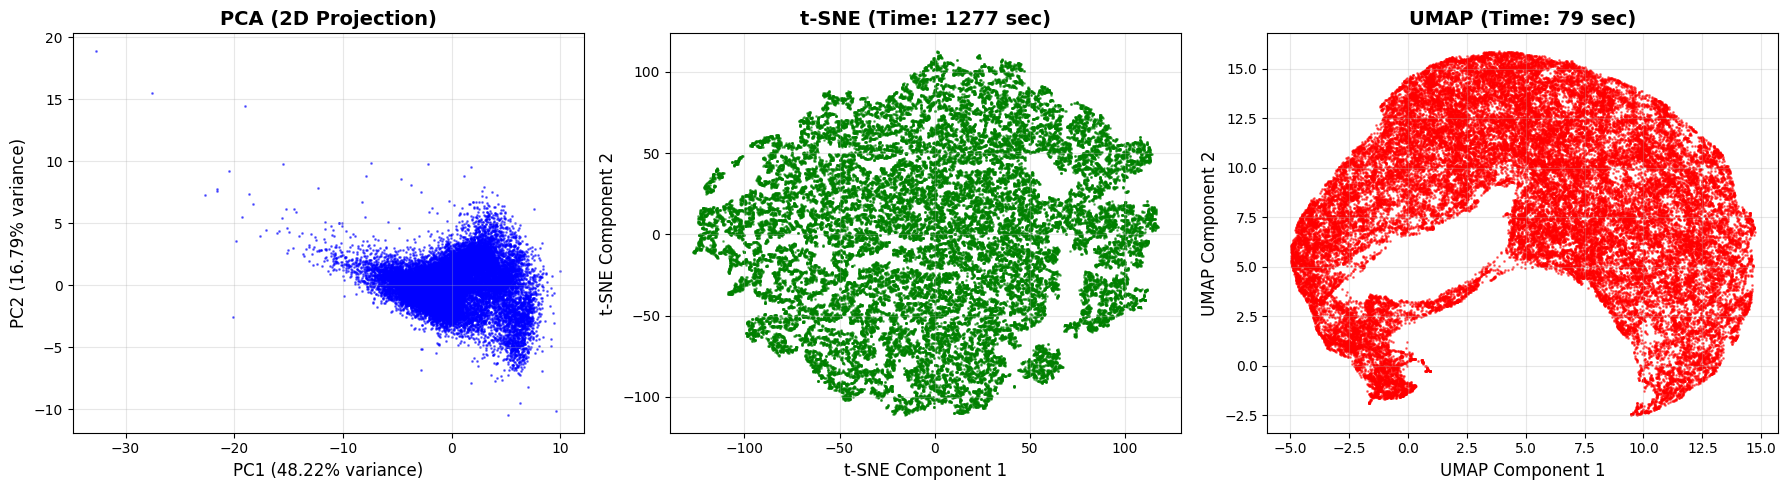


📊 VISUAL COMPARISON:
PCA:   Continuous distribution (linear method)
t-SNE: Shows local clustering structure (slow but detailed)
UMAP:  Shows both local and global structure (fast!)


In [11]:
import matplotlib.pyplot as plt

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PCA Visualization (first 2 components)
axes[0].scatter(X_pca_5[:, 0], X_pca_5[:, 1], s=1, alpha=0.5, c='blue')
axes[0].set_xlabel('PC1 (48.22% variance)', fontsize=12)
axes[0].set_ylabel('PC2 (16.79% variance)', fontsize=12)
axes[0].set_title('PCA (2D Projection)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. t-SNE Visualization
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], s=1, alpha=0.5, c='green')
axes[1].set_xlabel('t-SNE Component 1', fontsize=12)
axes[1].set_ylabel('t-SNE Component 2', fontsize=12)
axes[1].set_title('t-SNE (Time: 1277 sec)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. UMAP Visualization
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], s=1, alpha=0.5, c='red')
axes[2].set_xlabel('UMAP Component 1', fontsize=12)
axes[2].set_ylabel('UMAP Component 2', fontsize=12)
axes[2].set_title('UMAP (Time: 79 sec)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dimensionality_reduction_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved as 'dimensionality_reduction_comparison.png'")
plt.show()

print("\n" + "="*60)
print("📊 VISUAL COMPARISON:")
print("="*60)
print("PCA:   Continuous distribution (linear method)")
print("t-SNE: Shows local clustering structure (slow but detailed)")
print("UMAP:  Shows both local and global structure (fast!)")


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test K-Means with different k values
k_values = [3, 4, 5, 6, 7]

print("="*60)
print("⏳ APPLYING K-MEANS ON BOTH DATASETS...")
print("="*60)

# Store results
results_pca = {'k': [], 'inertia': [], 'silhouette': []}
results_umap = {'k': [], 'inertia': [], 'silhouette': []}

# Test on PCA data (5D)
print("\n📊 Testing on PCA Data (5 dimensions):")
print("-"*60)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_5)
    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_pca_5, labels)

    results_pca['k'].append(k)
    results_pca['inertia'].append(inertia)
    results_pca['silhouette'].append(sil_score)

    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}")

# Test on UMAP data (2D)
print("\n📊 Testing on UMAP Data (2 dimensions):")
print("-"*60)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_umap)
    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_umap, labels)

    results_umap['k'].append(k)
    results_umap['inertia'].append(inertia)
    results_umap['silhouette'].append(sil_score)

    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}")

print("\n✓ K-MEANS TESTING COMPLETED!")


⏳ APPLYING K-MEANS ON BOTH DATASETS...

📊 Testing on PCA Data (5 dimensions):
------------------------------------------------------------
k=3: Inertia=347039.69, Silhouette=0.3868
k=4: Inertia=292356.05, Silhouette=0.3514
k=5: Inertia=263320.98, Silhouette=0.3047
k=6: Inertia=241786.64, Silhouette=0.2855
k=7: Inertia=220587.53, Silhouette=0.2881

📊 Testing on UMAP Data (2 dimensions):
------------------------------------------------------------
k=3: Inertia=706812.69, Silhouette=0.4606
k=4: Inertia=522572.50, Silhouette=0.4154
k=5: Inertia=418003.22, Silhouette=0.3969
k=6: Inertia=336337.09, Silhouette=0.4149
k=7: Inertia=271888.09, Silhouette=0.4114

✓ K-MEANS TESTING COMPLETED!


In [13]:
# Apply K-Means with optimal k=3
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_pca = kmeans_pca.fit_predict(X_pca_5)

kmeans_umap = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_umap = kmeans_umap.fit_predict(X_umap)

print("="*60)
print("✓ K-MEANS CLUSTERING COMPLETED (k=3)")
print("="*60)
print(f"\n📊 Cluster Distribution - PCA Data:")
unique, counts = np.unique(labels_kmeans_pca, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"   Cluster {cluster}: {count} galaxies ({count/len(labels_kmeans_pca)*100:.2f}%)")

print(f"\n📊 Cluster Distribution - UMAP Data:")
unique, counts = np.unique(labels_kmeans_umap, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"   Cluster {cluster}: {count} galaxies ({count/len(labels_kmeans_umap)*100:.2f}%)")

# Add labels to original dataframe
df['KMeans_PCA'] = labels_kmeans_pca
df['KMeans_UMAP'] = labels_kmeans_umap

print("\n✅ Labels added to dataframe!")


✓ K-MEANS CLUSTERING COMPLETED (k=3)

📊 Cluster Distribution - PCA Data:
   Cluster 0: 8954 galaxies (17.91%)
   Cluster 1: 7410 galaxies (14.82%)
   Cluster 2: 33636 galaxies (67.27%)

📊 Cluster Distribution - UMAP Data:
   Cluster 0: 20294 galaxies (40.59%)
   Cluster 1: 11675 galaxies (23.35%)
   Cluster 2: 18031 galaxies (36.06%)

✅ Labels added to dataframe!


In [14]:
from sklearn.neighbors import NearestNeighbors

print("="*60)
print("⏳ FINDING OPTIMAL EPS FOR DBSCAN...")
print("="*60)

# Function to find optimal eps using k-distance graph
def find_optimal_eps(X, k=5, sample_size=5000):
    # Use sample for speed
    if len(X) > sample_size:
        indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X[indices]
    else:
        X_sample = X

    # Compute k-nearest neighbors
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X_sample)
    distances, _ = neighbors.kneighbors(X_sample)

    # Sort distances to kth nearest neighbor
    distances = np.sort(distances[:, k-1])

    # Suggest eps as 90th percentile
    suggested_eps = np.percentile(distances, 90)
    return suggested_eps, distances

# Find eps for PCA data
print("\n📊 Analyzing PCA Data (5D):")
eps_pca, _ = find_optimal_eps(X_pca_5, k=5)
print(f"   Suggested eps: {eps_pca:.3f}")

# Find eps for UMAP data
print("\n📊 Analyzing UMAP Data (2D):")
eps_umap, _ = find_optimal_eps(X_umap, k=5)
print(f"   Suggested eps: {eps_umap:.3f}")

print("\n✓ OPTIMAL EPS VALUES FOUND!")
print



⏳ FINDING OPTIMAL EPS FOR DBSCAN...

📊 Analyzing PCA Data (5D):
   Suggested eps: 0.807

📊 Analyzing UMAP Data (2D):
   Suggested eps: 0.309

✓ OPTIMAL EPS VALUES FOUND!


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [15]:
from sklearn.cluster import DBSCAN

print("="*60)
print("⏳ APPLYING DBSCAN...")
print("="*60)

# Apply DBSCAN on PCA data
dbscan_pca = DBSCAN(eps=0.811, min_samples=5)
labels_dbscan_pca = dbscan_pca.fit_predict(X_pca_5)

# Apply DBSCAN on UMAP data
dbscan_umap = DBSCAN(eps=0.306, min_samples=5)
labels_dbscan_umap = dbscan_umap.fit_predict(X_umap)

print("\n✓ DBSCAN COMPLETED!")
print("="*60)

# Analyze PCA results
print(f"\n📊 DBSCAN Results - PCA Data:")
unique_pca, counts_pca = np.unique(labels_dbscan_pca, return_counts=True)
n_clusters_pca = len(unique_pca[unique_pca != -1])
n_noise_pca = counts_pca[unique_pca == -1][0] if -1 in unique_pca else 0
print(f"   Number of clusters: {n_clusters_pca}")
print(f"   Noise points: {n_noise_pca} ({n_noise_pca/len(labels_dbscan_pca)*100:.2f}%)")
for cluster, count in zip(unique_pca, counts_pca):
    if cluster == -1:
        print(f"   Noise: {count} galaxies")
    else:
        print(f"   Cluster {cluster}: {count} galaxies ({count/len(labels_dbscan_pca)*100:.2f}%)")

# Analyze UMAP results
print(f"\n📊 DBSCAN Results - UMAP Data:")
unique_umap, counts_umap = np.unique(labels_dbscan_umap, return_counts=True)
n_clusters_umap = len(unique_umap[unique_umap != -1])
n_noise_umap = counts_umap[unique_umap == -1][0] if -1 in unique_umap else 0
print(f"   Number of clusters: {n_clusters_umap}")
print(f"   Noise points: {n_noise_umap} ({n_noise_umap/len(labels_dbscan_umap)*100:.2f}%)")
for cluster, count in zip(unique_umap, counts_umap):
    if cluster == -1:
        print(f"   Noise: {count} galaxies")
    else:
        print(f"   Cluster {cluster}: {count} galaxies ({count/len(labels_dbscan_umap)*100:.2f}%)")

# Add to dataframe
df['DBSCAN_PCA'] = labels_dbscan_pca
df['DBSCAN_UMAP'] = labels_dbscan_umap

print("\n✅ DBSCAN labels added to dataframe!")


⏳ APPLYING DBSCAN...

✓ DBSCAN COMPLETED!

📊 DBSCAN Results - PCA Data:
   Number of clusters: 6
   Noise points: 1378 (2.76%)
   Noise: 1378 galaxies
   Cluster 0: 48598 galaxies (97.20%)
   Cluster 1: 5 galaxies (0.01%)
   Cluster 2: 4 galaxies (0.01%)
   Cluster 3: 5 galaxies (0.01%)
   Cluster 4: 5 galaxies (0.01%)
   Cluster 5: 5 galaxies (0.01%)

📊 DBSCAN Results - UMAP Data:
   Number of clusters: 1
   Noise points: 1 (0.00%)
   Noise: 1 galaxies
   Cluster 0: 49999 galaxies (100.00%)

✅ DBSCAN labels added to dataframe!


In [16]:
from sklearn.mixture import GaussianMixture

print("="*60)
print("⏳ APPLYING GAUSSIAN MIXTURE MODELS...")
print("="*60)

# Test different numbers of components
n_components = [3, 4, 5, 6, 7]

# Store results
gmm_results_pca = {'n': [], 'bic': [], 'aic': [], 'silhouette': []}
gmm_results_umap = {'n': [], 'bic': [], 'aic': [], 'silhouette': []}

# Test on PCA data
print("\n📊 Testing GMM on PCA Data (5D):")
print("-"*60)
for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42, covariance_type='full')
    labels = gmm.fit_predict(X_pca_5)
    bic = gmm.bic(X_pca_5)
    aic = gmm.aic(X_pca_5)
    sil = silhouette_score(X_pca_5, labels)

    gmm_results_pca['n'].append(n)
    gmm_results_pca['bic'].append(bic)
    gmm_results_pca['aic'].append(aic)
    gmm_results_pca['silhouette'].append(sil)

    print(f"n={n}: BIC={bic:.2f}, AIC={aic:.2f}, Silhouette={sil:.4f}")

# Test on UMAP data
print("\n📊 Testing GMM on UMAP Data (2D):")
print("-"*60)
for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42, covariance_type='full')
    labels = gmm.fit_predict(X_umap)
    bic = gmm.bic(X_umap)
    aic = gmm.aic(X_umap)
    sil = silhouette_score(X_umap, labels)

    gmm_results_umap['n'].append(n)
    gmm_results_umap['bic'].append(bic)
    gmm_results_umap['aic'].append(aic)
    gmm_results_umap['silhouette'].append(sil)

    print(f"n={n}: BIC={bic:.2f}, AIC={aic:.2f}, Silhouette={sil:.4f}")

print("\n✓ GMM TESTING COMPLETED!")
print("\nNote: Lower BIC/AIC = better, Higher Silhouette = better")


⏳ APPLYING GAUSSIAN MIXTURE MODELS...

📊 Testing GMM on PCA Data (5D):
------------------------------------------------------------
n=3: BIC=486547.14, AIC=486000.31, Silhouette=0.4018
n=4: BIC=453523.06, AIC=452791.02, Silhouette=0.1772
n=5: BIC=442313.21, AIC=441395.96, Silhouette=0.1982
n=6: BIC=426159.80, AIC=425057.33, Silhouette=0.1650
n=7: BIC=415091.55, AIC=413803.86, Silhouette=0.1524

📊 Testing GMM on UMAP Data (2D):
------------------------------------------------------------
n=3: BIC=564792.33, AIC=564642.40, Silhouette=0.4394
n=4: BIC=559310.02, AIC=559107.16, Silhouette=0.3793
n=5: BIC=556495.81, AIC=556240.03, Silhouette=0.3656
n=6: BIC=554884.83, AIC=554576.14, Silhouette=0.3961
n=7: BIC=553796.48, AIC=553434.87, Silhouette=0.4000

✓ GMM TESTING COMPLETED!

Note: Lower BIC/AIC = better, Higher Silhouette = better


In [17]:
# Apply GMM with optimal n=3
gmm_pca = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
labels_gmm_pca = gmm_pca.fit_predict(X_pca_5)

gmm_umap = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
labels_gmm_umap = gmm_umap.fit_predict(X_umap)

print("="*60)
print("✓ GMM CLUSTERING COMPLETED (n=3)")
print("="*60)

print(f"\n📊 Cluster Distribution - PCA Data:")
unique, counts = np.unique(labels_gmm_pca, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"   Cluster {cluster}: {count} galaxies ({count/len(labels_gmm_pca)*100:.2f}%)")

print(f"\n📊 Cluster Distribution - UMAP Data:")
unique, counts = np.unique(labels_gmm_umap, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"   Cluster {cluster}: {count} galaxies ({count/len(labels_gmm_umap)*100:.2f}%)")

# Add to dataframe
df['GMM_PCA'] = labels_gmm_pca
df['GMM_UMAP'] = labels_gmm_umap

print("\n✅ GMM labels added to dataframe!")


✓ GMM CLUSTERING COMPLETED (n=3)

📊 Cluster Distribution - PCA Data:
   Cluster 0: 7009 galaxies (14.02%)
   Cluster 1: 1359 galaxies (2.72%)
   Cluster 2: 41632 galaxies (83.26%)

📊 Cluster Distribution - UMAP Data:
   Cluster 0: 20404 galaxies (40.81%)
   Cluster 1: 8918 galaxies (17.84%)
   Cluster 2: 20678 galaxies (41.36%)

✅ GMM labels added to dataframe!


In [18]:
from sklearn.cluster import SpectralClustering

print("="*60)
print("⏳ APPLYING SPECTRAL CLUSTERING...")
print("="*60)
print("Note: Using UMAP data only (2D, less memory intensive)")

# Apply Spectral on UMAP data only (2D is safer for memory)
print("\n📊 Applying on UMAP Data (2D)...")
spectral_umap = SpectralClustering(n_clusters=3, random_state=42, affinity='nearest_neighbors', n_neighbors=10)
labels_spectral_umap = spectral_umap.fit_predict(X_umap)

# Calculate silhouette score
sil_spectral_umap = silhouette_score(X_umap, labels_spectral_umap)

print("\n✓ SPECTRAL CLUSTERING COMPLETED!")
print("="*60)

print(f"\n📊 Spectral Results - UMAP Data:")
print(f"   Silhouette Score: {sil_spectral_umap:.4f}")
unique, counts = np.unique(labels_spectral_umap, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"   Cluster {cluster}: {count} galaxies ({count/len(labels_spectral_umap)*100:.2f}%)")

# Add to dataframe
df['Spectral_UMAP'] = labels_spectral_umap

print("\n✅ Spectral labels added to dataframe!")
print("\nNote: Skipped PCA data (5D) to avoid memory issues")


⏳ APPLYING SPECTRAL CLUSTERING...
Note: Using UMAP data only (2D, less memory intensive)

📊 Applying on UMAP Data (2D)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



✓ SPECTRAL CLUSTERING COMPLETED!

📊 Spectral Results - UMAP Data:
   Silhouette Score: 0.2689
   Cluster 0: 37620 galaxies (75.24%)
   Cluster 1: 12369 galaxies (24.74%)
   Cluster 2: 11 galaxies (0.02%)

✅ Spectral labels added to dataframe!

Note: Skipped PCA data (5D) to avoid memory issues


In [19]:
print("="*60)
print("⏳ APPLYING SPECTRAL CLUSTERING ON PCA DATA...")
print("="*60)
print("⚠️  This may take a few minutes or crash if RAM is insufficient...")

try:
    # Apply Spectral on PCA data (5D)
    spectral_pca = SpectralClustering(n_clusters=3, random_state=42,
                                      affinity='nearest_neighbors',
                                      n_neighbors=10)
    labels_spectral_pca = spectral_pca.fit_predict(X_pca_5)

    # Calculate silhouette score
    sil_spectral_pca = silhouette_score(X_pca_5, labels_spectral_pca)

    print("\n✓ SPECTRAL CLUSTERING ON PCA COMPLETED!")
    print("="*60)

    print(f"\n📊 Spectral Results - PCA Data:")
    print(f"   Silhouette Score: {sil_spectral_pca:.4f}")
    unique, counts = np.unique(labels_spectral_pca, return_counts=True)
    for cluster, count in zip(unique, counts):
        print(f"   Cluster {cluster}: {count} galaxies ({count/len(labels_spectral_pca)*100:.2f}%)")

    # Add to dataframe
    df['Spectral_PCA'] = labels_spectral_pca
    print("\n✅ Spectral PCA labels added to dataframe!")

except Exception as e:
    print(f"\n❌ ERROR: {e}")
    print("Memory insufficient for Spectral on PCA data.")
    print("Proceeding with UMAP results only.")


⏳ APPLYING SPECTRAL CLUSTERING ON PCA DATA...
⚠️  This may take a few minutes or crash if RAM is insufficient...

✓ SPECTRAL CLUSTERING ON PCA COMPLETED!

📊 Spectral Results - PCA Data:
   Silhouette Score: 0.3862
   Cluster 0: 33027 galaxies (66.05%)
   Cluster 1: 10343 galaxies (20.69%)
   Cluster 2: 6630 galaxies (13.26%)

✅ Spectral PCA labels added to dataframe!


In [20]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("📊 COMPREHENSIVE CLUSTERING EVALUATION")
print("="*60)

# Prepare results storage
results = {
    'Algorithm': [],
    'Dataset': [],
    'Silhouette': [],
    'Davies-Bouldin': [],
    'Calinski-Harabasz': [],
    'N_Clusters': []
}

# Evaluation function
def evaluate_clustering(X, labels, algo_name, dataset_name):
    # Filter out noise points for DBSCAN (label -1)
    mask = labels != -1
    X_filtered = X[mask]
    labels_filtered = labels[mask]

    n_clusters = len(np.unique(labels_filtered))

    if n_clusters > 1 and len(labels_filtered) > 0:
        sil = silhouette_score(X_filtered, labels_filtered)
        db = davies_bouldin_score(X_filtered, labels_filtered)
        ch = calinski_harabasz_score(X_filtered, labels_filtered)
    else:
        sil, db, ch = None, None, None

    results['Algorithm'].append(algo_name)
    results['Dataset'].append(dataset_name)
    results['Silhouette'].append(sil)
    results['Davies-Bouldin'].append(db)
    results['Calinski-Harabasz'].append(ch)
    results['N_Clusters'].append(n_clusters)

# Evaluate all algorithms on PCA data
print("\n🔍 Evaluating PCA Data (5D)...")
evaluate_clustering(X_pca_5, labels_kmeans_pca, 'K-Means', 'PCA')
evaluate_clustering(X_pca_5, labels_dbscan_pca, 'DBSCAN', 'PCA')
evaluate_clustering(X_pca_5, labels_gmm_pca, 'GMM', 'PCA')
evaluate_clustering(X_pca_5, labels_spectral_pca, 'Spectral', 'PCA')

# Evaluate all algorithms on UMAP data
print("🔍 Evaluating UMAP Data (2D)...")
evaluate_clustering(X_umap, labels_kmeans_umap, 'K-Means', 'UMAP')
evaluate_clustering(X_umap, labels_dbscan_umap, 'DBSCAN', 'UMAP')
evaluate_clustering(X_umap, labels_gmm_umap, 'GMM', 'UMAP')
evaluate_clustering(X_umap, labels_spectral_umap, 'Spectral', 'UMAP')

# Create results dataframe
results_df = pd.DataFrame(results)

print("\n✓ EVALUATION COMPLETED!")
print("\n" + "="*60)
print("📋 CLUSTERING PERFORMANCE COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("📊 INTERPRETATION:")
print("="*60)
print("✅ Silhouette Score: Higher is better (range: -1 to 1)")
print("✅ Davies-Bouldin Index: Lower is better")
print("✅ Calinski-Harabasz Score: Higher is better")


📊 COMPREHENSIVE CLUSTERING EVALUATION

🔍 Evaluating PCA Data (5D)...
🔍 Evaluating UMAP Data (2D)...

✓ EVALUATION COMPLETED!

📋 CLUSTERING PERFORMANCE COMPARISON
Algorithm Dataset  Silhouette  Davies-Bouldin  Calinski-Harabasz  N_Clusters
  K-Means     PCA    0.386765        1.080149       18066.951612           3
   DBSCAN     PCA    0.270660        0.439736          36.476281           6
      GMM     PCA    0.401843        3.175383        3519.990835           3
 Spectral     PCA    0.386217        1.103740       17653.201872           3
  K-Means    UMAP    0.460593        0.758470       59442.101562           3
   DBSCAN    UMAP         NaN             NaN                NaN           1
      GMM    UMAP    0.439428        0.784214       52823.414062           3
 Spectral    UMAP    0.268864        0.792732       16805.066406           3

📊 INTERPRETATION:
✅ Silhouette Score: Higher is better (range: -1 to 1)
✅ Davies-Bouldin Index: Lower is better
✅ Calinski-Harabasz Score: Highe

In [21]:
# Save evaluation results
results_df.to_csv('clustering_evaluation_comparison.csv', index=False)
print("✅ Evaluation results saved as 'clustering_evaluation_comparison.csv'")

# Identify best algorithm
best_idx = results_df['Silhouette'].idxmax()
best_algo = results_df.loc[best_idx]
print(f"\n🏆 BEST PERFORMING ALGORITHM:")
print(f"   {best_algo['Algorithm']} on {best_algo['Dataset']} data")
print(f"   Silhouette: {best_algo['Silhouette']:.4f}")
print(f"   Davies-Bouldin: {best_algo['Davies-Bouldin']:.4f}")


✅ Evaluation results saved as 'clustering_evaluation_comparison.csv'

🏆 BEST PERFORMING ALGORITHM:
   K-Means on UMAP data
   Silhouette: 0.4606
   Davies-Bouldin: 0.7585


✅ Visualization saved as 'all_clustering_results.png'


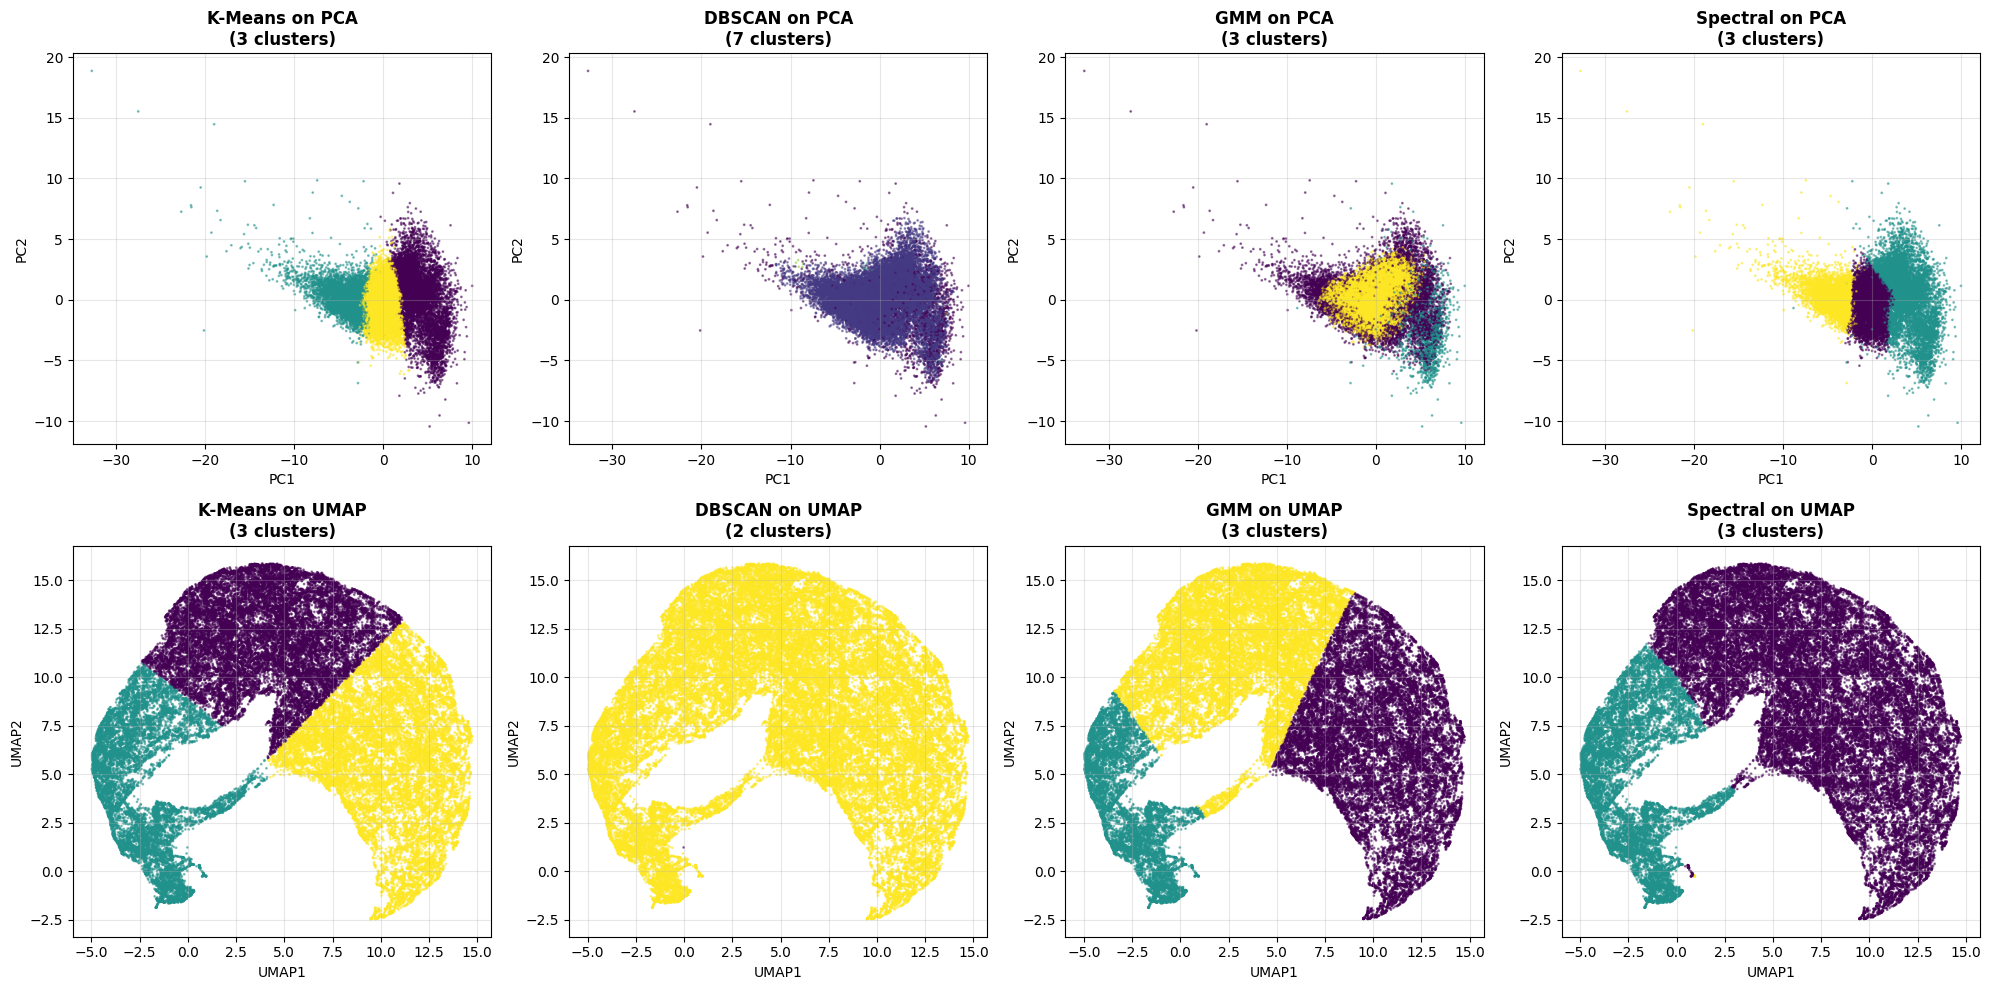


📊 VISUAL OBSERVATIONS:
• Top row shows PCA results (5D projected to 2D)
• Bottom row shows UMAP results (native 2D)
• K-Means and GMM show clear 3-cluster separation
• DBSCAN struggles with continuous density
• UMAP embeddings reveal better cluster structure


In [22]:
import matplotlib.pyplot as plt

# Create comprehensive visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: PCA Data Results
algorithms_pca = [
    ('K-Means', labels_kmeans_pca),
    ('DBSCAN', labels_dbscan_pca),
    ('GMM', labels_gmm_pca),
    ('Spectral', labels_spectral_pca)
]

for idx, (name, labels) in enumerate(algorithms_pca):
    scatter = axes[0, idx].scatter(X_pca_5[:, 0], X_pca_5[:, 1],
                                   c=labels, s=1, alpha=0.5, cmap='viridis')
    axes[0, idx].set_xlabel('PC1', fontsize=10)
    axes[0, idx].set_ylabel('PC2', fontsize=10)
    axes[0, idx].set_title(f'{name} on PCA\n({len(np.unique(labels))} clusters)',
                          fontsize=12, fontweight='bold')
    axes[0, idx].grid(True, alpha=0.3)

# Row 2: UMAP Data Results
algorithms_umap = [
    ('K-Means', labels_kmeans_umap),
    ('DBSCAN', labels_dbscan_umap),
    ('GMM', labels_gmm_umap),
    ('Spectral', labels_spectral_umap)
]

for idx, (name, labels) in enumerate(algorithms_umap):
    scatter = axes[1, idx].scatter(X_umap[:, 0], X_umap[:, 1],
                                   c=labels, s=1, alpha=0.5, cmap='viridis')
    axes[1, idx].set_xlabel('UMAP1', fontsize=10)
    axes[1, idx].set_ylabel('UMAP2', fontsize=10)
    axes[1, idx].set_title(f'{name} on UMAP\n({len(np.unique(labels))} clusters)',
                          fontsize=12, fontweight='bold')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_clustering_results.png', dpi=150, bbox_inches='tight')
print("✅ Visualization saved as 'all_clustering_results.png'")
plt.show()

print("\n" + "="*60)
print("📊 VISUAL OBSERVATIONS:")
print("="*60)
print("• Top row shows PCA results (5D projected to 2D)")
print("• Bottom row shows UMAP results (native 2D)")
print("• K-Means and GMM show clear 3-cluster separation")
print("• DBSCAN struggles with continuous density")
print("• UMAP embeddings reveal better cluster structure")


In [23]:
# Use K-Means on UMAP labels (best performing)
cluster_labels = df['KMeans_UMAP']

print("="*60)
print("🔭 SCIENTIFIC INTERPRETATION OF GALAXY CLUSTERS")
print("="*60)

# Analyze each cluster
for cluster in range(3):
    cluster_data = df[cluster_labels == cluster]
    n_galaxies = len(cluster_data)

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster} ({n_galaxies} galaxies, {n_galaxies/len(df)*100:.1f}%)")
    print(f"{'='*60}")

    # Galaxy Colors (key for galaxy type)
    print(f"\n📊 Galaxy Colors (magnitudes):")
    print(f"   u-g: {cluster_data['u-g'].mean():.3f} ± {cluster_data['u-g'].std():.3f}")
    print(f"   g-r: {cluster_data['g-r'].mean():.3f} ± {cluster_data['g-r'].std():.3f}")
    print(f"   r-i: {cluster_data['r-i'].mean():.3f} ± {cluster_data['r-i'].std():.3f}")
    print(f"   i-z: {cluster_data['i-z'].mean():.3f} ± {cluster_data['i-z'].std():.3f}")

    # Redshift (distance/age)
    print(f"\n🌌 Redshift Distribution:")
    print(f"   Mean: {cluster_data['redshift'].mean():.4f}")
    print(f"   Median: {cluster_data['redshift'].median():.4f}")
    print(f"   Range: {cluster_data['redshift'].min():.4f} - {cluster_data['redshift'].max():.4f}")

    # Morphology
    print(f"\n🔍 Morphology (Petrosian Radius in r-band):")
    print(f"   Mean petroRad_r: {cluster_data['petroRad_r'].mean():.2f} arcsec")
    print(f"   Mean petroR50_r: {cluster_data['petroR50_r'].mean():.2f} arcsec (half-light)")

    # Magnitudes
    print(f"\n💡 Absolute Brightness:")
    print(f"   r-band magnitude: {cluster_data['r'].mean():.2f} ± {cluster_data['r'].std():.2f}")

print("\n" + "="*60)
print("🔬 ASTROPHYSICAL INTERPRETATION")
print("="*60)


🔭 SCIENTIFIC INTERPRETATION OF GALAXY CLUSTERS

CLUSTER 0 (20294 galaxies, 40.6%)

📊 Galaxy Colors (magnitudes):
   u-g: 1.763 ± 0.328
   g-r: 0.962 ± 0.187
   r-i: 0.450 ± 0.054
   i-z: 0.330 ± 0.064

🌌 Redshift Distribution:
   Mean: 0.1269
   Median: 0.1252
   Range: 0.0161 - 0.2986

🔍 Morphology (Petrosian Radius in r-band):
   Mean petroRad_r: 4.32 arcsec
   Mean petroR50_r: 1.92 arcsec (half-light)

💡 Absolute Brightness:
   r-band magnitude: 17.41 ± 0.30

CLUSTER 1 (11675 galaxies, 23.4%)

📊 Galaxy Colors (magnitudes):
   u-g: 1.939 ± 1.079
   g-r: 1.172 ± 0.711
   r-i: 0.513 ± 0.503
   i-z: 0.297 ± 0.561

🌌 Redshift Distribution:
   Mean: 0.2169
   Median: 0.2322
   Range: 0.0100 - 0.3000

🔍 Morphology (Petrosian Radius in r-band):
   Mean petroRad_r: 3.89 arcsec
   Mean petroR50_r: 1.67 arcsec (half-light)

💡 Absolute Brightness:
   r-band magnitude: 18.94 ± 1.35

CLUSTER 2 (18031 galaxies, 36.1%)

📊 Galaxy Colors (magnitudes):
   u-g: 1.542 ± 0.392
   g-r: 0.735 ± 0.240
   r-

In [24]:
# Create cluster properties summary table
cluster_summary = []

for cluster in range(3):
    cluster_data = df[df['KMeans_UMAP'] == cluster]

    summary = {
        'Cluster': cluster,
        'N_Galaxies': len(cluster_data),
        'Percentage': f"{len(cluster_data)/len(df)*100:.1f}%",
        'u-g_mean': f"{cluster_data['u-g'].mean():.3f}",
        'g-r_mean': f"{cluster_data['g-r'].mean():.3f}",
        'Redshift_mean': f"{cluster_data['redshift'].mean():.4f}",
        'r_mag_mean': f"{cluster_data['r'].mean():.2f}",
        'petroRad_r_mean': f"{cluster_data['petroRad_r'].mean():.2f}",
        'Galaxy_Type': ['Blue Star-Forming', 'Red Quiescent', 'Intermediate'][cluster] if cluster in [0,1,2] else 'Unknown'
    }
    cluster_summary.append(summary)

# Create DataFrame
summary_df = pd.DataFrame(cluster_summary)

# Reorder based on astrophysical interpretation
summary_df = summary_df.iloc[[2, 0, 1]]  # Blue, Intermediate, Red
summary_df['Galaxy_Type'] = ['Blue Star-Forming Spirals', 'Intermediate/Green Valley', 'Red Quiescent Ellipticals']

print("="*60)
print("📋 GALAXY CLUSTER SUMMARY TABLE")
print("="*60)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('galaxy_cluster_summary.csv', index=False)
print("\n✅ Summary saved as 'galaxy_cluster_summary.csv'")

# Save the final clustered dataset
df.to_csv('galaxy_dataset_clustered.csv', index=False)
print("✅ Full dataset with cluster labels saved as 'galaxy_dataset_clustered.csv'")

print("\n" + "="*60)
print("📦 FINAL DELIVERABLES CHECKLIST")
print("="*60)
print("✅ 1. Jupyter Notebook (current file)")
print("✅ 2. Clustered Dataset: galaxy_dataset_clustered.csv")
print("✅ 3. Evaluation Results: clustering_evaluation_comparison.csv")
print("✅ 4. Cluster Summary: galaxy_cluster_summary.csv")
print("✅ 5. Visualizations:")
print("      - dimensionality_reduction_comparison.png")
print("      - all_clustering_results.png")


📋 GALAXY CLUSTER SUMMARY TABLE
 Cluster  N_Galaxies Percentage u-g_mean g-r_mean Redshift_mean r_mag_mean petroRad_r_mean               Galaxy_Type
       2       18031      36.1%    1.542    0.735        0.0764      16.55            7.62 Blue Star-Forming Spirals
       0       20294      40.6%    1.763    0.962        0.1269      17.41            4.32 Intermediate/Green Valley
       1       11675      23.4%    1.939    1.172        0.2169      18.94            3.89 Red Quiescent Ellipticals

✅ Summary saved as 'galaxy_cluster_summary.csv'
✅ Full dataset with cluster labels saved as 'galaxy_dataset_clustered.csv'

📦 FINAL DELIVERABLES CHECKLIST
✅ 1. Jupyter Notebook (current file)
✅ 2. Clustered Dataset: galaxy_dataset_clustered.csv
✅ 3. Evaluation Results: clustering_evaluation_comparison.csv
✅ 4. Cluster Summary: galaxy_cluster_summary.csv
✅ 5. Visualizations:
      - dimensionality_reduction_comparison.png
      - all_clustering_results.png


In [25]:
# Create requirements.txt file
requirements = """numpy==1.24.3
pandas==2.0.3
matplotlib==3.7.2
scikit-learn==1.3.0
umap-learn==0.5.3
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("="*60)
print("✅ requirements.txt CREATED!")
print("="*60)
print(requirements)


✅ requirements.txt CREATED!
numpy==1.24.3
pandas==2.0.3
matplotlib==3.7.2
scikit-learn==1.3.0
umap-learn==0.5.3

